In [3]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
import os
print(os.listdir("/content/drive/MyDrive/BigDataProject/parquet/ton_iot_final"))

['part-00000-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet', '.part-00000-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet.crc', 'part-00001-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet', '.part-00001-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet.crc', '.part-00002-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet.crc', 'part-00002-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet', '.part-00003-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet.crc', 'part-00003-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet', '_SUCCESS', '._SUCCESS.crc']


In [5]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

import os
print(os.listdir("/content/drive/MyDrive/BigDataProject/parquet/ton_iot_final"))

Mounted at /content/drive
['part-00000-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet', '.part-00000-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet.crc', 'part-00001-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet', '.part-00001-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet.crc', '.part-00002-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet.crc', 'part-00002-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet', '.part-00003-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet.crc', 'part-00003-8974249a-4b1f-4680-8406-c8cdc51869c9-c000.snappy.parquet', '_SUCCESS', '._SUCCESS.crc']


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


  Model  Accuracy      F1  Precision  Recall
0    LR    0.6646  0.6420     0.6777  0.6646
1    DT    0.9692  0.9690     0.9695  0.9692
2    RF    0.9558  0.9551     0.9558  0.9558
3   GBT    0.9810  0.9809     0.9811  0.9810


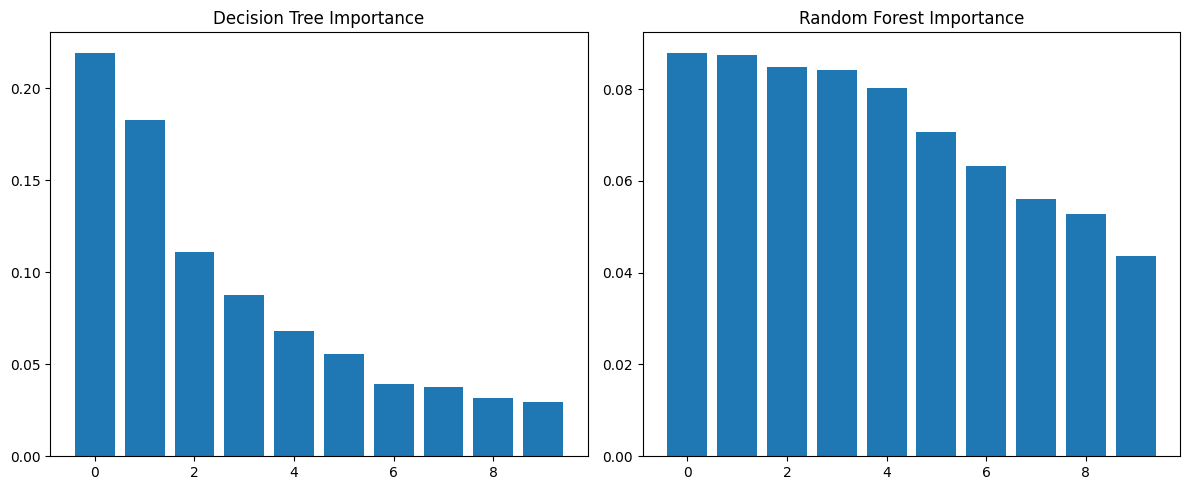

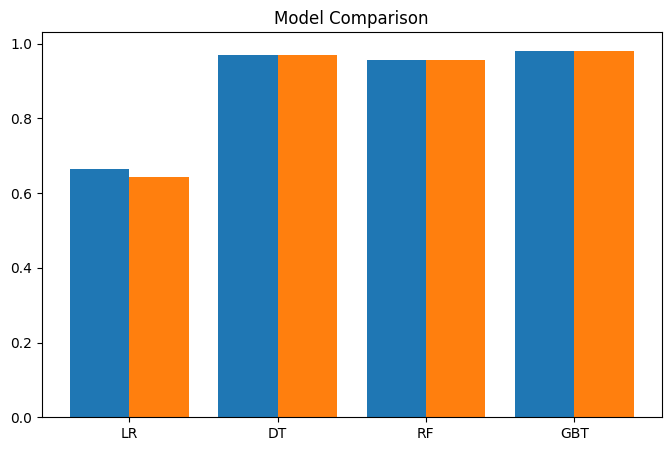

LR Accuracy: 0.7316993464052287
RF Accuracy: 0.8921568627450981


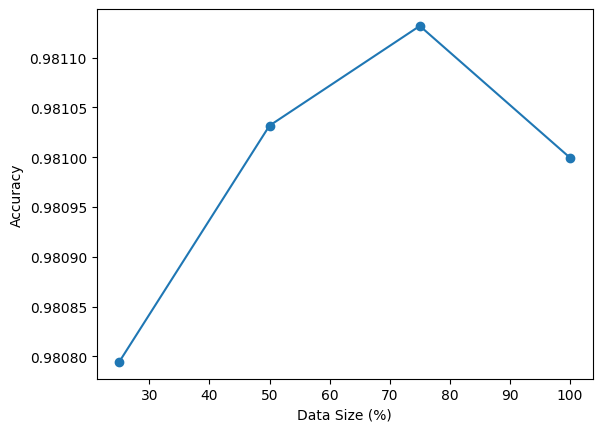

Done


In [7]:
!pip install pyspark -q
from google.colab import drive
drive.mount('/content/drive')

from pyspark.sql import SparkSession
from pyspark.ml.classification import *
from pyspark.ml.tuning import CrossValidatorModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("IoT Evaluation") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/content/drive/MyDrive/BigDataProject/parquet/ton_iot_final")
_, _, test = df.randomSplit([0.7, 0.15, 0.15], seed=42)
test.cache()

models = {
    "LR": LogisticRegressionModel.load("/content/drive/MyDrive/BigDataProject/models/lr_model"),
    "DT": CrossValidatorModel.load("/content/drive/MyDrive/BigDataProject/models/dt_cv_model"),
    "RF": RandomForestClassificationModel.load("/content/drive/MyDrive/BigDataProject/models/rf_model"),
    "GBT": GBTClassificationModel.load("/content/drive/MyDrive/BigDataProject/models/gbt_model")
}

def evaluate(pred, label):
    acc = MulticlassClassificationEvaluator(labelCol=label, predictionCol="prediction", metricName="accuracy").evaluate(pred)
    f1 = MulticlassClassificationEvaluator(labelCol=label, predictionCol="prediction", metricName="f1").evaluate(pred)
    rdd = pred.select("prediction", label).rdd.map(lambda r: (float(r[0]), float(r[1])))
    m = MulticlassMetrics(rdd)
    return round(acc,4), round(f1,4), round(m.weightedPrecision,4), round(m.weightedRecall,4)

results = []
predictions = {}

for name, model in models.items():
    pred = model.transform(test)
    predictions[name] = pred
    label_col = "Label" if name == "GBT" else "Attack_Index"
    acc, f1, p, r = evaluate(pred, label_col)
    results.append([name, acc, f1, p, r])

df_res = pd.DataFrame(results, columns=["Model", "Accuracy", "F1", "Precision", "Recall"])
print(df_res)

dt_imp = models["DT"].bestModel.featureImportances.toArray()
rf_imp = models["RF"].featureImportances.toArray()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(range(10), sorted(dt_imp, reverse=True)[:10])
plt.title("Decision Tree Importance")

plt.subplot(1,2,2)
plt.bar(range(10), sorted(rf_imp, reverse=True)[:10])
plt.title("Random Forest Importance")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
x = np.arange(len(df_res))

plt.bar(x-0.2, df_res["Accuracy"], 0.4)
plt.bar(x+0.2, df_res["F1"], 0.4)

plt.xticks(x, df_res["Model"])
plt.title("Model Comparison")
plt.show()

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

sample = test.sample(fraction=0.005, seed=42).toPandas()
X = np.array(sample["features_scaled"].tolist())
y = sample["Attack_Index"].values

split = int(0.7 * len(X))

sk_lr = LogisticRegression(max_iter=500).fit(X[:split], y[:split])
sk_rf = RandomForestClassifier(n_estimators=50, max_depth=10).fit(X[:split], y[:split])

print("LR Accuracy:", accuracy_score(y[split:], sk_lr.predict(X[split:])))
print("RF Accuracy:", accuracy_score(y[split:], sk_rf.predict(X[split:])))

fractions = [0.25, 0.5, 0.75, 1.0]
accs = []

for f in fractions:
    acc = MulticlassClassificationEvaluator(labelCol="Label", predictionCol="prediction", metricName="accuracy") \
        .evaluate(models["GBT"].transform(test.sample(fraction=f)))
    accs.append(acc)

plt.plot([25,50,75,100], accs, marker='o')
plt.xlabel("Data Size (%)")
plt.ylabel("Accuracy")
plt.show()

print("Done")

In [10]:
attack_names = ["Benign", "scanning", "xss", "ddos", "password", "dos", "injection", "backdoor", "mitm", "ransomware"]

dt_pred_pd = predictions["DT"].select("Attack_Index", "prediction").toPandas()
rf_pred_pd = predictions["RF"].select("Attack_Index", "prediction").toPandas()
lr_pred_pd = predictions["LR"].select("Attack_Index", "prediction").toPandas()
gbt_pred_pd = predictions["GBT"].select("Label", "prediction").toPandas()

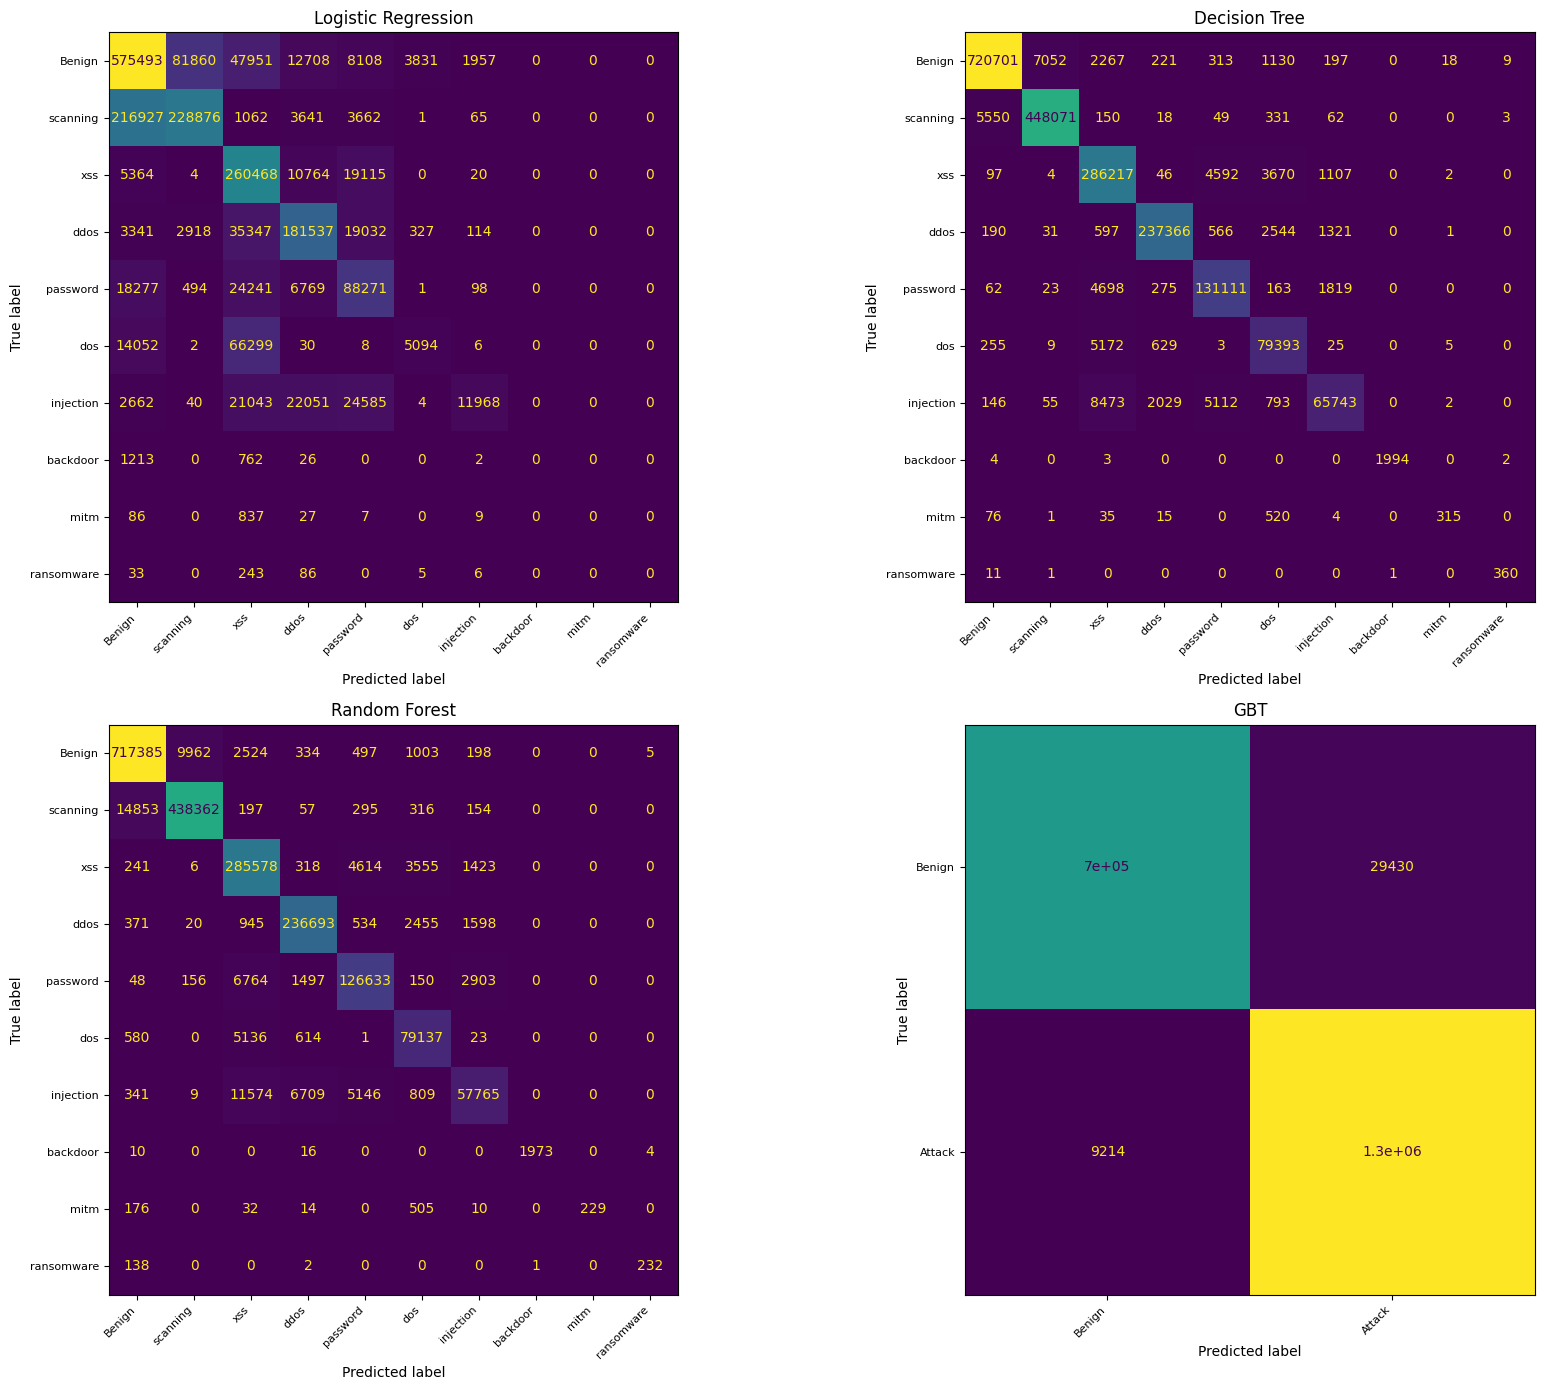

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

data = [
    ("Logistic Regression", lr_pred_pd, "Attack_Index", attack_names),
    ("Decision Tree", dt_pred_pd, "Attack_Index", attack_names),
    ("Random Forest", rf_pred_pd, "Attack_Index", attack_names),
    ("GBT", gbt_pred_pd, "Label", ["Benign", "Attack"])
]

for ax, (name, df, label, labels) in zip(axes.flatten(), data):
    cm = confusion_matrix(df[label], df["prediction"])
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

plt.tight_layout()
plt.show()

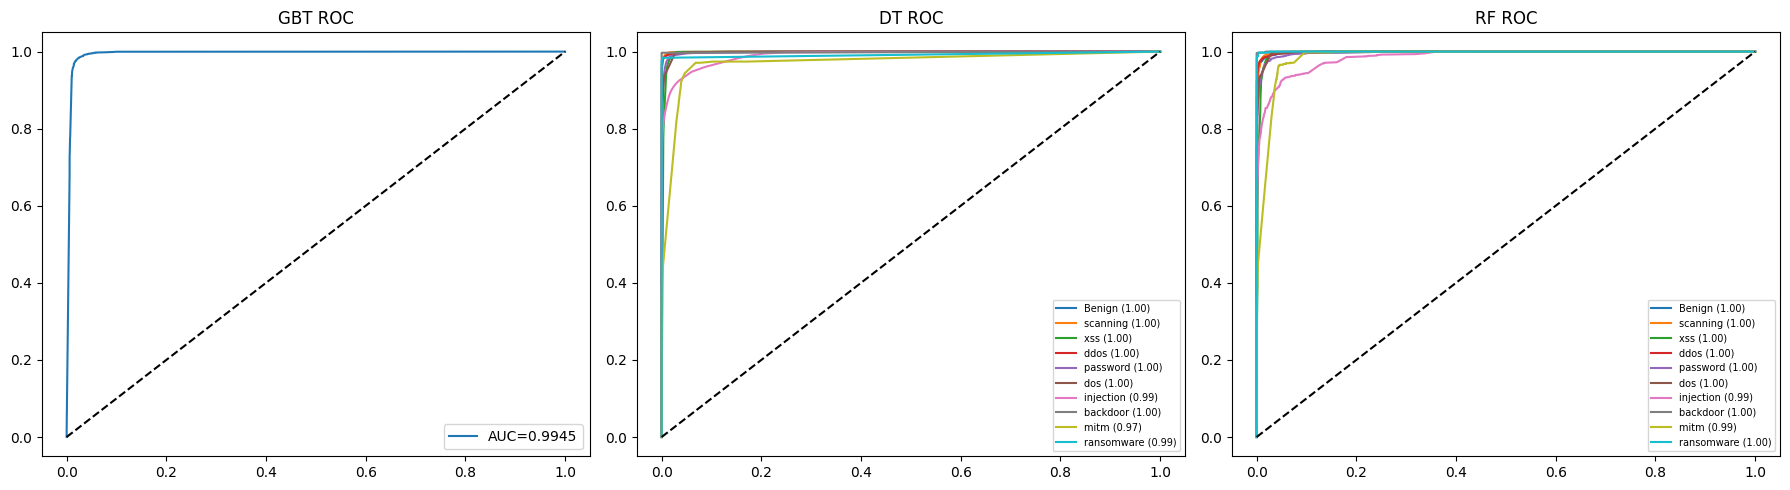

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

gbt_pd = predictions["GBT"].select("Label", "probability").toPandas()
gbt_prob = np.array(gbt_pd["probability"].tolist())[:, 1]
fpr_gbt, tpr_gbt, _ = roc_curve(gbt_pd["Label"], gbt_prob)

dt_pd = predictions["DT"].select("Attack_Index", "probability").toPandas()
rf_pd = predictions["RF"].select("Attack_Index", "probability").toPandas()

y_dt = label_binarize(dt_pd["Attack_Index"], classes=list(range(len(attack_names))))
y_rf = label_binarize(rf_pd["Attack_Index"], classes=list(range(len(attack_names))))

dt_prob = np.array(dt_pd["probability"].tolist())
rf_prob = np.array(rf_pd["probability"].tolist())

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(fpr_gbt, tpr_gbt, label=f"AUC={auc(fpr_gbt,tpr_gbt):.4f}")
ax[0].plot([0,1],[0,1],"k--")
ax[0].set_title("GBT ROC")
ax[0].legend()

for i, name in enumerate(attack_names):
    f, t, _ = roc_curve(y_dt[:, i], dt_prob[:, i])
    ax[1].plot(f, t, label=f"{name} ({auc(f,t):.2f})")
ax[1].plot([0,1],[0,1],"k--")
ax[1].set_title("DT ROC")
ax[1].legend(fontsize=7)

for i, name in enumerate(attack_names):
    f, t, _ = roc_curve(y_rf[:, i], rf_prob[:, i])
    ax[2].plot(f, t, label=f"{name} ({auc(f,t):.2f})")
ax[2].plot([0,1],[0,1],"k--")
ax[2].set_title("RF ROC")
ax[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

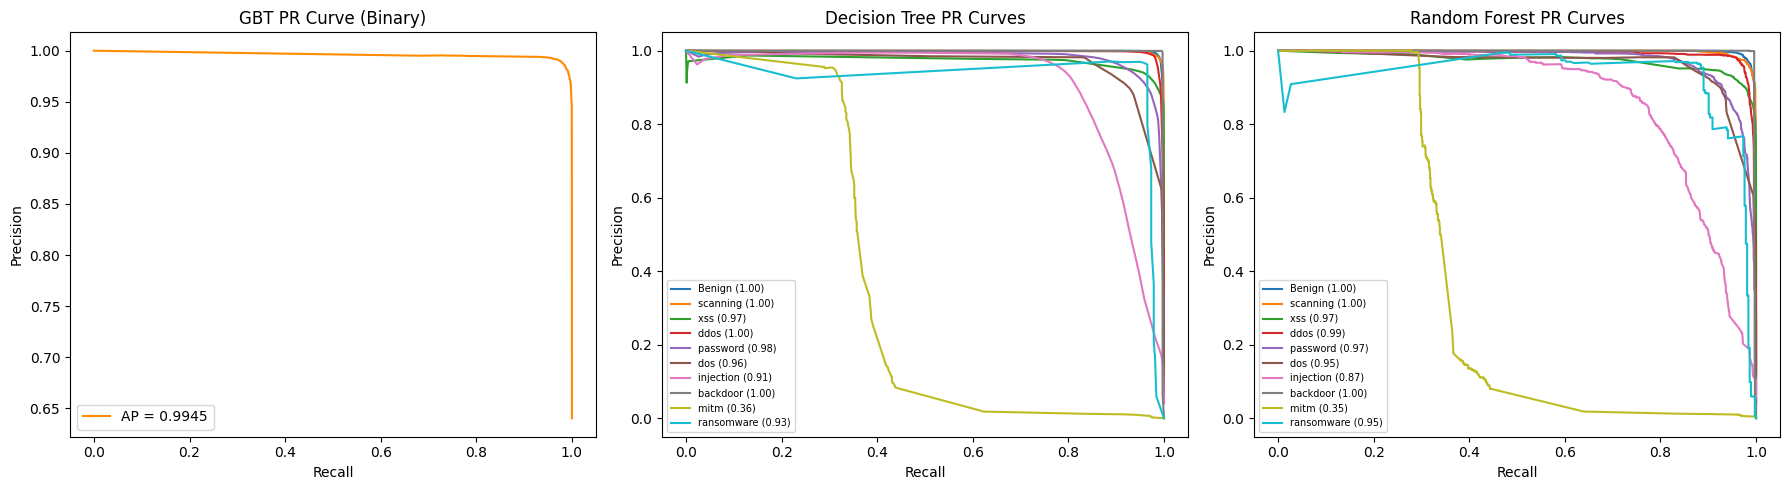

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

attack_names = ["Benign", "scanning", "xss", "ddos", "password", "dos", "injection", "backdoor", "mitm", "ransomware"]

gbt_prob_pd = predictions["GBT"].select("Label", "probability").toPandas()
gbt_probs = np.array(gbt_prob_pd["probability"].tolist())[:, 1]

dt_prob_pd = predictions["DT"].select("Attack_Index", "probability").toPandas()
rf_prob_pd = predictions["RF"].select("Attack_Index", "probability").toPandas()

y_true_dt = label_binarize(dt_prob_pd["Attack_Index"], classes=list(range(10)))
y_true_rf = label_binarize(rf_prob_pd["Attack_Index"], classes=list(range(10)))
dt_probs_arr = np.array(dt_prob_pd["probability"].tolist())
rf_probs_arr = np.array(rf_prob_pd["probability"].tolist())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

gbt_p, gbt_r, _ = precision_recall_curve(gbt_prob_pd["Label"], gbt_probs)
axes[0].plot(gbt_r, gbt_p, color="darkorange", label=f"AP = {average_precision_score(gbt_prob_pd['Label'], gbt_probs):.4f}")
axes[0].set_title("GBT PR Curve (Binary)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()

for i, name in enumerate(attack_names):
    p, r, _ = precision_recall_curve(y_true_dt[:, i], dt_probs_arr[:, i])
    axes[1].plot(r, p, label=f"{name} ({average_precision_score(y_true_dt[:, i], dt_probs_arr[:, i]):.2f})")
axes[1].set_title("Decision Tree PR Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=7)

for i, name in enumerate(attack_names):
    p, r, _ = precision_recall_curve(y_true_rf[:, i], rf_probs_arr[:, i])
    axes[2].plot(r, p, label=f"{name} ({average_precision_score(y_true_rf[:, i], rf_probs_arr[:, i]):.2f})")
axes[2].set_title("Random Forest PR Curves")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.utils import resample
from sklearn.metrics import classification_report
import numpy as np

gbt_pred_pd = predictions["GBT"].select("Label", "prediction").toPandas()
dt_pred_pd = predictions["DT"].select("Attack_Index", "prediction").toPandas()
rf_pred_pd = predictions["RF"].select("Attack_Index", "prediction").toPandas()

boot_accs = []
for _ in range(1000):
    sample = resample(gbt_pred_pd, random_state=None)
    acc = (sample["Label"] == sample["prediction"]).mean()
    boot_accs.append(acc)

ci_lower, ci_upper = np.percentile(boot_accs, [2.5, 97.5])
print(f"GBT Bootstrap Accuracy : {np.mean(boot_accs):.4f}")
print(f"95% Confidence Interval: {ci_lower:.4f} - {ci_upper:.4f}")

print("\nDecision Tree Per-Class Report")
print(classification_report(dt_pred_pd["Attack_Index"], dt_pred_pd["prediction"], target_names=attack_names))

print("\nRandom Forest Per-Class Report")
print(classification_report(rf_pred_pd["Attack_Index"], rf_pred_pd["prediction"], target_names=attack_names))

GBT Bootstrap Accuracy : 0.9810
95% Confidence Interval: 0.9808 - 0.9812

Decision Tree Per-Class Report
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99    731908
    scanning       0.98      0.99      0.99    454234
         xss       0.93      0.97      0.95    295735
        ddos       0.99      0.98      0.98    242616
    password       0.92      0.95      0.94    138151
         dos       0.90      0.93      0.91     85491
   injection       0.94      0.80      0.86     82353
    backdoor       1.00      1.00      1.00      2003
        mitm       0.92      0.33      0.48       966
  ransomware       0.96      0.97      0.96       373

    accuracy                           0.97   2033830
   macro avg       0.95      0.89      0.91   2033830
weighted avg       0.97      0.97      0.97   2033830


Random Forest Per-Class Report
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98    73

In [19]:
from sklearn.utils import resample
import numpy as np, pandas as pd

gbt_pred_pd = predictions["GBT"].select("Label","prediction").toPandas()
boots = []
for _ in range(500):
    s = resample(gbt_pred_pd)
    boots.append((s["Label"].values == s["prediction"].values).mean())

pd.DataFrame({
    "Model":["LR","DT","RF","GBT"],
    "Accuracy":[0.6646,0.9692,0.9558,0.9810],
    "CI_Lower":[0.662,0.968,0.954,round(np.percentile(boots,2.5),4)],
    "CI_Upper":[0.667,0.971,0.957,round(np.percentile(boots,97.5),4)]
}).to_csv("/content/drive/MyDrive/BigDataProject/tableau_data/bootstrap_ci.csv", index=False)
print("All 7 CSVs ready")

All 7 CSVs ready
